In [1]:
import pandas as pd
# Load the training and test datasets
train_data = pd.read_excel("YVR_prcp_training_rev1.xlsx")
test_data = pd.read_excel("YVR_prcp_testing_rev1.xlsx")

In [2]:
# PCP prediction

In [3]:
train_data

,y,x1,x2,x3
0,0.840896,2.762058,0.245517,1.232369
1,1.538321,1.657333,1.480955,1.353424
2,1.551876,0.440495,0.705076,0.433408
3,1.377449,-1.230265,-0.389113,-0.857842
4,1.231493,-3.093805,-0.675591,-2.302428
...,...,...,...,...
3995,1.189207,-0.318320,0.489222,0.352705
3996,1.087757,-0.027099,0.807532,0.740080
3997,1.000000,0.290099,1.603305,1.248510
3998,1.316074,-0.550750,1.379494,1.563252


In [4]:
test_data

,y,x1,x2,x3
0,2.150817,0.132867,4.472069,1.966768
1,1.829382,-1.022446,3.410706,1.095174
2,2.120010,-1.001937,0.548905,0.578674
3,1.967990,-1.371090,1.647073,0.304283
4,1.231493,0.164314,1.005481,0.933768
...,...,...,...,...
975,1.722347,1.807729,0.756801,0.933768
976,1.987381,1.541118,0.435508,1.087104
977,1.524398,1.591706,-0.711401,0.594814
978,1.046635,1.315525,0.632462,0.925697


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separate predictors and response variable for training and test datasets
X_train = train_data[['x1', 'x2', 'x3']].values
y_train = train_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

X_test = test_data[['x1', 'x2', 'x3']].values
y_test = test_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

# Build the Random Forest regression model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Compute Pearson correlation
corr = np.corrcoef(y_test, y_pred)[0, 1]

print("Random Forest Regression:")
print(f"RMSE: {rmse}")
print(f"Pearson correlation: {corr}")


Random Forest Regression:
RMSE: 0.08972901471169617
Pearson correlation: 0.2609940122525464


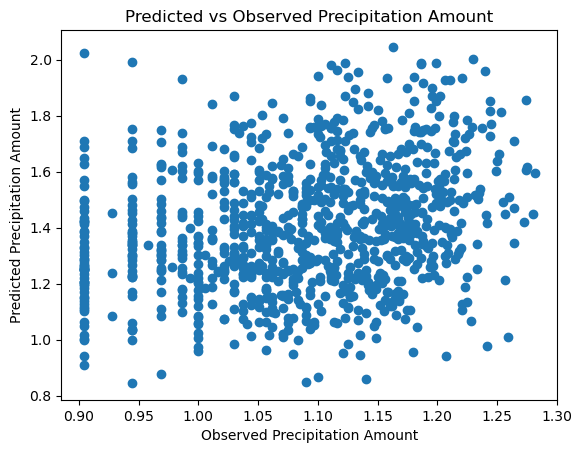

In [6]:
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_transformed = model.predict(X_test)


# Reverse the fourth root transformation
y_test_transformed = np.power(y_test, 4)
y_pred = np.power(y_pred_transformed, 4)

# Plot predicted vs observed
plt.scatter(y_test, y_pred)
plt.xlabel("Observed Precipitation Amount")
plt.ylabel("Predicted Precipitation Amount")
plt.title("Predicted vs Observed Precipitation Amount")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separate predictors and response variable for training and test datasets
X_train = train_data[['x1', 'x2', 'x3']].values
y_train = train_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

X_test = test_data[['x1', 'x2', 'x3']].values
y_test = test_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

# Build the Random Forest regression model
#model = RandomForestRegressor(n_estimators=100, random_state=42)
from sklearn.ensemble import GradientBoostingRegressor

# Create and fit Gradient Boosting Regression model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Compute Pearson correlation
corr = np.corrcoef(y_test, y_pred)[0, 1]

print("Random Forest Regression:")
print(f"RMSE: {rmse}")
print(f"Pearson correlation: {corr}")

Random Forest Regression:
RMSE: 0.08613604318062014
Pearson correlation: 0.3118435511159043


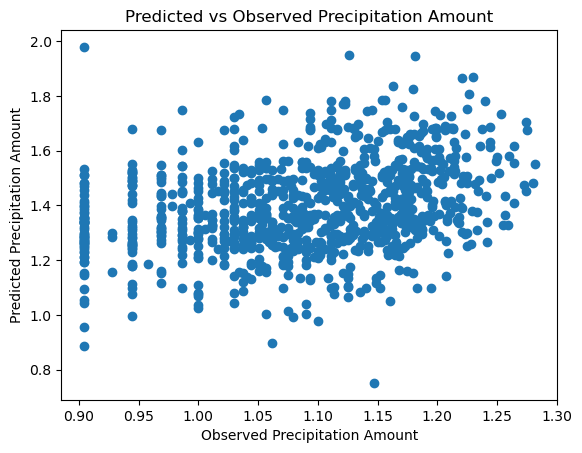

In [8]:
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_transformed = model.predict(X_test)


# Reverse the fourth root transformation
y_test_transformed = np.power(y_test, 4)
y_pred = np.power(y_pred_transformed, 4)

# Plot predicted vs observed
plt.scatter(y_test, y_pred)
plt.xlabel("Observed Precipitation Amount")
plt.ylabel("Predicted Precipitation Amount")
plt.title("Predicted vs Observed Precipitation Amount")
plt.show()

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Separate predictors and response variable for training and test datasets
X_train = train_data[['x1', 'x2', 'x3']].values
y_train = train_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

X_test = test_data[['x1', 'x2', 'x3']].values
y_test = test_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform



# Create a Sequential model
model = Sequential()

# Add input layer
model.add(Dense(64, activation='relu', input_shape=(3,)))

# Add hidden layers
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Add output layer
model.add(Dense(1, activation='linear'))  # Linear activation for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print("Mean Squared Error:", mse)


/glade/u/home/kumar34/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6373 - val_loss: 0.0575
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0341 - val_loss: 0.0111
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0100 - val_loss: 0.0092
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079 - val_loss: 0.0086
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - val_loss: 0.0087
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - val_loss: 0.0084
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - val_loss: 0.0082
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - val_loss: 0.0081
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079 - val_loss: 0.0081
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072 - val_loss: 0.0080
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0075 - val_loss: 0.0080
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━

In [27]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Reshape y_pred to match the shape of y_test
y_pred = y_pred.reshape(-1)

# Compute Pearson correlation
corr = np.corrcoef(y_test, y_pred)[0, 1]

print("Neural Network model")
print(f"RMSE: {rmse}")
print(f"Pearson correlation: {corr}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network model
RMSE: 0.08905487307636517
Pearson correlation: 0.28245691790068217


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step


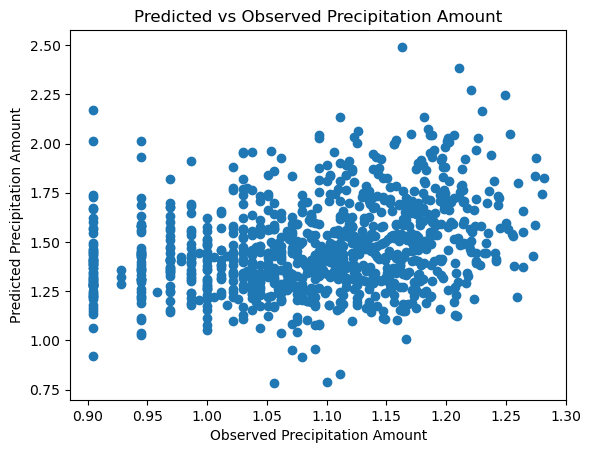

In [28]:
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_transformed = model.predict(X_test)


# Reverse the fourth root transformation
y_test_transformed = np.power(y_test, 4)
y_pred = np.power(y_pred_transformed, 4)

# Plot predicted vs observed
plt.scatter(y_test, y_pred)
plt.xlabel("Observed Precipitation Amount")
plt.ylabel("Predicted Precipitation Amount")
plt.title("Predicted vs Observed Precipitation Amount")
plt.show()

In [29]:

# CNN model for PCP prediction
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.metrics import mean_squared_error
import numpy as np

# Separate predictors and response variable for training and test datasets
X_train = train_data[['x1', 'x2', 'x3']].values
y_train = train_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

X_test = test_data[['x1', 'x2', 'x3']].values
y_test = test_data['y'].apply(lambda x: np.power(x, 1/4)).values  # Applying fourth root transform

# Reshape inputs for Conv1D: (samples, timesteps/features, channels)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Create a 1D CNN model
cnn_model = Sequential()

# Add convolution layers
cnn_model.add(Conv1D(filters=64, kernel_size=2, activation='relu', padding='same', input_shape=(X_train_cnn.shape[1], 1)))
cnn_model.add(Conv1D(filters=32, kernel_size=2, activation='relu', padding='same'))

# Optional pooling layer
cnn_model.add(MaxPooling1D(pool_size=1))

# Flatten and dense layers
cnn_model.add(Flatten())
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dense(16, activation='relu'))
cnn_model.add(Dense(1, activation='linear'))  # Linear activation for regression

# Compile the model
cnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
cnn_model.summary()

# Train the model
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


/glade/u/home/kumar34/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 3, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 3, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,969 (31.13 KB)

 Trainable params: 7,969 (31.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4572 - val_loss: 0.0126
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0083 - val_loss: 0.0088
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0076 - val_loss: 0.0087
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0074 - val_loss: 0.0078
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0073 - val_loss: 0.0076
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0075 - val_loss: 0.0078
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0074 - val_loss: 0.0075
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - val_loss: 0.0081
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0076 - val_loss: 0.0076
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071 - val_loss: 0.0079
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076 - val_loss: 0.0078
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━

In [30]:

# Evaluate CNN model
cnn_pred = cnn_model.predict(X_test_cnn)

# Compute RMSE
cnn_rmse = np.sqrt(mean_squared_error(y_test, cnn_pred))

# Reshape predictions to match y_test
cnn_pred = cnn_pred.reshape(-1)

# Compute Pearson correlation
cnn_corr = np.corrcoef(y_test, cnn_pred)[0, 1]

print("CNN model")
print(f"RMSE: {cnn_rmse}")
print(f"Pearson correlation: {cnn_corr}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN model
RMSE: 0.08541549206118053
Pearson correlation: 0.3329944365624117


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step


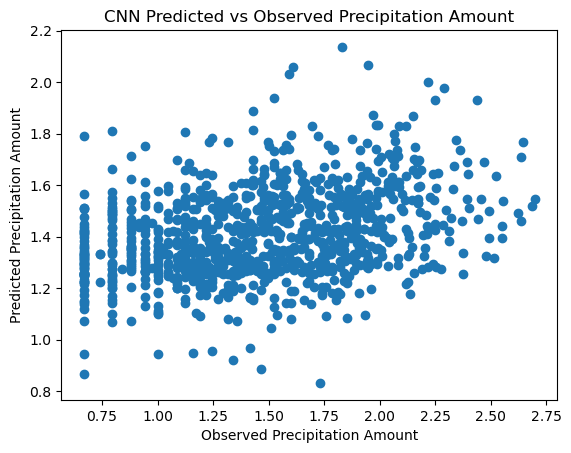

In [31]:

import matplotlib.pyplot as plt

# Make predictions on the test set
cnn_pred_transformed = cnn_model.predict(X_test_cnn)

# Reverse the fourth root transformation
y_test_transformed = np.power(y_test, 4)
cnn_pred_final = np.power(cnn_pred_transformed, 4)

# Plot predicted vs observed
plt.scatter(y_test_transformed, cnn_pred_final)
plt.xlabel("Observed Precipitation Amount")
plt.ylabel("Predicted Precipitation Amount")
plt.title("CNN Predicted vs Observed Precipitation Amount")
plt.show()
